In [1]:
import os
os.chdir(r"E:\Future Interns\Task 2 - Support Ticket Classification\Code")
os.getcwd()

'E:\\Future Interns\\Task 2 - Support Ticket Classification\\Code'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [3]:
df=pd.read_csv("task_df.csv")
df.head()

,Document,Topic_group,Clean Text,Word Count,Priority
0,connection with icon icon dear please setup ic...,hardware,connection icon setup per detail,5,Medium
1,work experience user work experience user hi w...,access,work experience user student come next name mu...,10,Medium
2,requesting for meeting requesting meeting hi p...,hardware,request meet meeting follow equipment cable co...,8,Medium
3,reset passwords for external accounts re expir...,access,reset password external account expire day ask...,67,High
4,mail verification warning hi has got attached ...,miscellaneous,mail verification warn attach address regard m...,8,Medium


In [4]:
#----------VECTORIZATION (FEATURE EXTRACTION)-------
df.isnull().sum()

Document       0
Topic_group    0
Clean Text     0
Word Count     0
Priority       0
dtype: int64

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
tfidf=TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

In [7]:
X_tfidf=tfidf.fit_transform(df['Clean Text'])
X_tfidf.shape

(47831, 5000)

In [8]:
features=tfidf.get_feature_names_out()
features[:50]

array(['ability', 'able', 'able access', 'able connect', 'able log',
       'able submit', 'able use', 'absence', 'absence contact',
       'absence leave', 'absence record', 'absence update', 'absences',
       'accept', 'accept decline', 'accept invitation', 'accept job',
       'accept language', 'accept liability', 'accept loss', 'accept try',
       'acceptance', 'acceptance test', 'accepts',
       'accepts responsibility', 'access', 'access account', 'access add',
       'access application', 'access approve', 'access area',
       'access assign', 'access card', 'access click', 'access client',
       'access colleague', 'access com', 'access confluence',
       'access create', 'access document', 'access error', 'access file',
       'access floor', 'access folder', 'access git', 'access give',
       'access good', 'access grant', 'access guy', 'access importance'],
      dtype=object)

In [9]:
tfidf_df = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=features
)
tfidf_df

,ability,able,able access,able connect,able log,able submit,able use,absence,absence contact,absence leave,...,yes mime,yesterday,yet,yet receive,zephyr,zero,zip,zone,zone award,zone computer
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
print("Shape:", X_tfidf.shape)
print("Non-zero values:", X_tfidf.nnz)

sparsity_tfidf = 100 * (1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))
print(f"Sparsity: {sparsity_tfidf:.2f}%")

Shape: (47831, 5000)
Non-zero values: 1101789
Sparsity: 99.54%


In [11]:
from sklearn.feature_extraction.text import CountVectorizer

In [12]:
bow=CountVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

In [13]:
X_bow=bow.fit_transform(df['Clean Text'])
features_bow=bow.get_feature_names_out()
features_bow[:50]

array(['ability', 'able', 'able access', 'able connect', 'able log',
       'able submit', 'able use', 'absence', 'absence contact',
       'absence leave', 'absence record', 'absence update', 'absences',
       'accept', 'accept decline', 'accept invitation', 'accept job',
       'accept language', 'accept liability', 'accept loss', 'accept try',
       'acceptance', 'acceptance test', 'accepts',
       'accepts responsibility', 'access', 'access account', 'access add',
       'access application', 'access approve', 'access area',
       'access assign', 'access card', 'access click', 'access client',
       'access colleague', 'access com', 'access confluence',
       'access create', 'access document', 'access error', 'access file',
       'access floor', 'access folder', 'access git', 'access give',
       'access good', 'access grant', 'access guy', 'access importance'],
      dtype=object)

In [14]:
print("Shape:", X_bow.shape)
print("Non-zero values:", X_bow.nnz)

sparsity_bow = 100 * (1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]))
print(f"Sparsity: {sparsity_bow:.2f}%")

Shape: (47831, 5000)
Non-zero values: 1101789
Sparsity: 99.54%


In [15]:
bow_df = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=features_bow
)

bow_df.head()

,ability,able,able access,able connect,able log,able submit,able use,absence,absence contact,absence leave,...,yes mime,yesterday,yet,yet receive,zephyr,zero,zip,zone,zone award,zone computer
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
#------CLASSIFICATION-------
y_topic=df['Topic_group']
y_priority=df['Priority']

In [17]:
#model training
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [18]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

In [26]:
def evaluate_models(X, y, feature_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results.append({
            "Feature Extraction": feature_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(
                y_test,
                y_pred,
                average='weighted'
            ),
            "Recall": recall_score(
                y_test,
                y_pred,
                average='weighted'
            ),
            "F1 Score": f1_score(
                y_test,
                y_pred,
                average='weighted'
            )
        })
        print(f"{name} done")
    return pd.DataFrame(results)

In [20]:
bow_topic_results = evaluate_models(
    X_bow,
    y_topic,
    "Bag of Words"
)

bow_topic_results

Naive Bayes done
Logistic Regression done
Linear SVM done
Random Forest done


,Feature Extraction,Model,Accuracy,Precision,Recall,F1 Score
0,Bag of Words,Naive Bayes,0.735967,0.747322,0.735967,0.736880
1,Bag of Words,Logistic Regression,0.806731,0.807941,0.806731,0.806792
2,Bag of Words,Linear SVM,0.793248,0.793362,0.793248,0.793074
3,Bag of Words,Random Forest,0.819170,0.821754,0.819170,0.818761


In [21]:
tfidf_topic_results = evaluate_models(
    X_tfidf,
    y_topic,
    "TF-IDF"
)

tfidf_topic_results

Naive Bayes done
Logistic Regression done
Linear SVM done
Random Forest done


,Feature Extraction,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF,Naive Bayes,0.733563,0.762255,0.733563,0.729636
1,TF-IDF,Logistic Regression,0.810599,0.816155,0.810599,0.810644
2,TF-IDF,Linear SVM,0.811958,0.813627,0.811958,0.811939
3,TF-IDF,Random Forest,0.811644,0.816908,0.811644,0.811522


In [22]:
topic_results = pd.concat(
    [bow_topic_results, tfidf_topic_results],
    ignore_index=True
)

topic_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Feature Extraction,Model,Accuracy,Precision,Recall,F1 Score
3,Bag of Words,Random Forest,0.819170,0.821754,0.819170,0.818761
6,TF-IDF,Linear SVM,0.811958,0.813627,0.811958,0.811939
7,TF-IDF,Random Forest,0.811644,0.816908,0.811644,0.811522
5,TF-IDF,Logistic Regression,0.810599,0.816155,0.810599,0.810644
1,Bag of Words,Logistic Regression,0.806731,0.807941,0.806731,0.806792
2,Bag of Words,Linear SVM,0.793248,0.793362,0.793248,0.793074
0,Bag of Words,Naive Bayes,0.735967,0.747322,0.735967,0.736880
4,TF-IDF,Naive Bayes,0.733563,0.762255,0.733563,0.729636


In [23]:
bow_priority_results = evaluate_models(
    X_bow,
    y_priority,
    "Bag of Words"
)

bow_priority_results

Naive Bayes done
Logistic Regression done
Linear SVM done
Random Forest done


,Feature Extraction,Model,Accuracy,Precision,Recall,F1 Score
0,Bag of Words,Naive Bayes,0.791471,0.821546,0.791471,0.801889
1,Bag of Words,Logistic Regression,0.895788,0.891650,0.895788,0.891497
2,Bag of Words,Linear SVM,0.891084,0.886761,0.891084,0.887098
3,Bag of Words,Random Forest,0.899132,0.898917,0.899132,0.889445


In [24]:
tfidf_priority_results = evaluate_models(
    X_tfidf,
    y_priority,
    "TF-IDF"
)

tfidf_priority_results

Naive Bayes done
Logistic Regression done
Linear SVM done
Random Forest done


,Feature Extraction,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF,Naive Bayes,0.840180,0.834326,0.840180,0.816968
1,TF-IDF,Logistic Regression,0.891293,0.887782,0.891293,0.881758
2,TF-IDF,Linear SVM,0.899132,0.895802,0.899132,0.892735
3,TF-IDF,Random Forest,0.897251,0.897850,0.897251,0.886451


In [25]:
priority_results = pd.concat(
    [bow_priority_results, tfidf_priority_results],
    ignore_index=True
)

priority_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Feature Extraction,Model,Accuracy,Precision,Recall,F1 Score
3,Bag of Words,Random Forest,0.899132,0.898917,0.899132,0.889445
6,TF-IDF,Linear SVM,0.899132,0.895802,0.899132,0.892735
7,TF-IDF,Random Forest,0.897251,0.897850,0.897251,0.886451
1,Bag of Words,Logistic Regression,0.895788,0.891650,0.895788,0.891497
5,TF-IDF,Logistic Regression,0.891293,0.887782,0.891293,0.881758
2,Bag of Words,Linear SVM,0.891084,0.886761,0.891084,0.887098
4,TF-IDF,Naive Bayes,0.840180,0.834326,0.840180,0.816968
0,Bag of Words,Naive Bayes,0.791471,0.821546,0.791471,0.801889


In [47]:
def evaluate_final_model(X, y, feature_name):
    import joblib
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    final_results = []
    final_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,     # Use all CPU cores
        verbose=1
    )
    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)
    final_results.append({
            "Output Label": feature_name,
            "Model": "Random Forest",
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(
                y_test,
                y_pred,
                average='weighted'
            ),
            "Recall": recall_score(
                y_test,
                y_pred,
                average='weighted'
            ),
            "F1 Score": f1_score(
                y_test,
                y_pred,
                average='weighted'
            )
        })
    model_name="final_model"+str(feature_name)

    joblib.dump(final_model, f"random_forest_{model_name}.pkl")

    from sklearn.metrics import classification_report

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
    
    report_df = pd.DataFrame(report).transpose()
    print(report_df)
    report_df.to_csv(
        f"classification_report_{feature_name}.csv",
        index=True
    )
    cm = confusion_matrix(y_test, y_pred)
    labels = sorted(y.unique())
    plt.figure(figsize=(10,8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=labels,
        yticklabels=labels,
        cmap='Blues'
    )
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix"+str(feature_name))
    plt.savefig(f"confusion_matrix_{feature_name}.png", dpi=300, bbox_inches='tight')
    plt.show()
    return pd.DataFrame(final_results)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   19.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.8min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.5s finished


                       precision    recall  f1-score     support
access                  0.862188  0.873684  0.867898  1425.00000
administrative rights   0.878151  0.593750  0.708475   352.00000
hardware                0.771954  0.832905  0.801272  2723.00000
hr support              0.817453  0.841044  0.829081  2183.00000
internal project        0.845570  0.787736  0.815629   424.00000
miscellaneous           0.790990  0.758499  0.774403  1412.00000
purchase                0.948775  0.864097  0.904459   493.00000
storage                 0.890656  0.807207  0.846881   555.00000
accuracy                0.819170  0.819170  0.819170     0.81917
macro avg               0.850717  0.794865  0.818512  9567.00000
weighted avg            0.821754  0.819170  0.818761  9567.00000


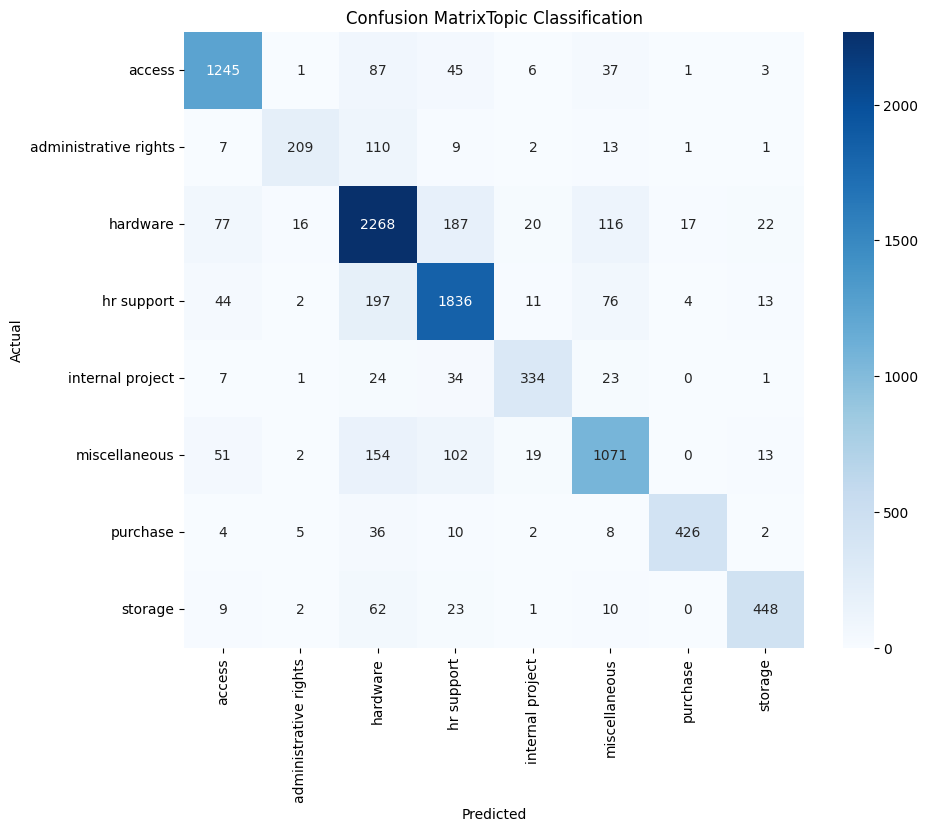

,Output Label,Model,Accuracy,Precision,Recall,F1 Score
0,Topic Classification,Random Forest,0.81917,0.821754,0.81917,0.818761


In [48]:
bow_topic_final_result = evaluate_final_model(
    X_bow,
    y_topic,
    "Topic Classification"
)

bow_topic_final_result

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   57.9s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.1min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.5s finished


              precision    recall  f1-score      support
Critical       0.928331  0.646127  0.761938  1704.000000
High           0.877083  0.848790  0.862705   496.000000
Low            0.804688  0.323899  0.461883   318.000000
Medium         0.897594  0.989786  0.941438  7049.000000
accuracy       0.899132  0.899132  0.899132     0.899132
macro avg      0.876924  0.702151  0.756991  9567.000000
weighted avg   0.898917  0.899132  0.889445  9567.000000


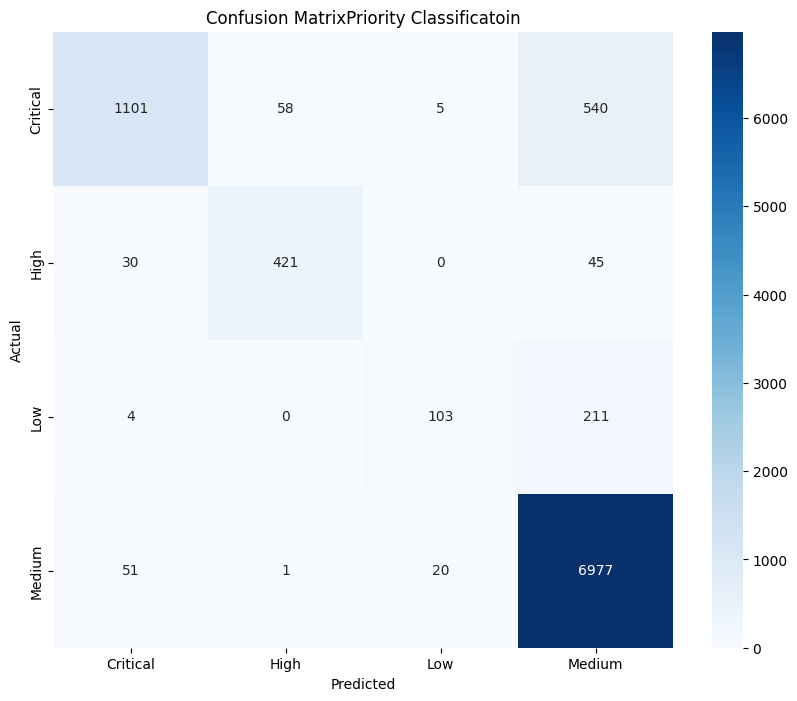

,Output Label,Model,Accuracy,Precision,Recall,F1 Score
0,Priority Classificatoin,Random Forest,0.899132,0.898917,0.899132,0.889445


In [49]:
bow_priority_final_result = evaluate_final_model(
    X_bow,
    y_priority,
    "Priority Classificatoin"
)

bow_priority_final_result

In [44]:
final_results = pd.concat(
    [bow_topic_final_result, bow_priority_final_result],
    ignore_index=True
)

final_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Output Label,Model,Accuracy,Precision,Recall,F1 Score
1,Priority Classificatoin,Random Forest,0.899132,0.898917,0.899132,0.889445
0,Topic Classification,Random Forest,0.819170,0.821754,0.819170,0.818761


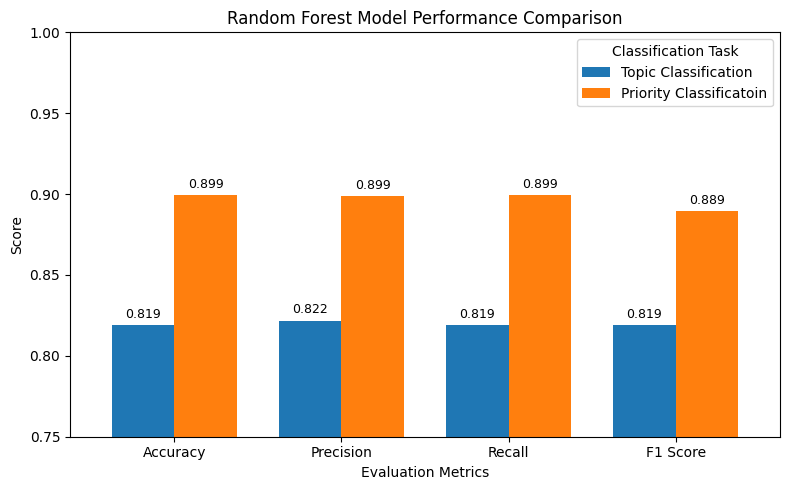

In [45]:
import matplotlib.pyplot as plt

plot_df = final_results.set_index("Output Label")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].T

ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.75
)

ax.set_title("Random Forest Model Performance Comparison")
ax.set_xlabel("Evaluation Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0.75, 1.0)
plt.xticks(rotation=0)
plt.legend(title="Classification Task")
# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",      # Display 3 decimal places
        padding=3,
        fontsize=9
    )
plt.tight_layout()
plt.show()

In [46]:
joblib.dump(bow, "count_vectorizer.pkl")

['count_vectorizer.pkl']

                   Topic  precision    recall  f1-score  support
0                 access   0.862188  0.873684  0.867898   1425.0
1  administrative rights   0.878151  0.593750  0.708475    352.0
2               hardware   0.771954  0.832905  0.801272   2723.0
3             hr support   0.817453  0.841044  0.829081   2183.0
4       internal project   0.845570  0.787736  0.815629    424.0
5          miscellaneous   0.790990  0.758499  0.774403   1412.0
6               purchase   0.948775  0.864097  0.904459    493.0
7                storage   0.890656  0.807207  0.846881    555.0


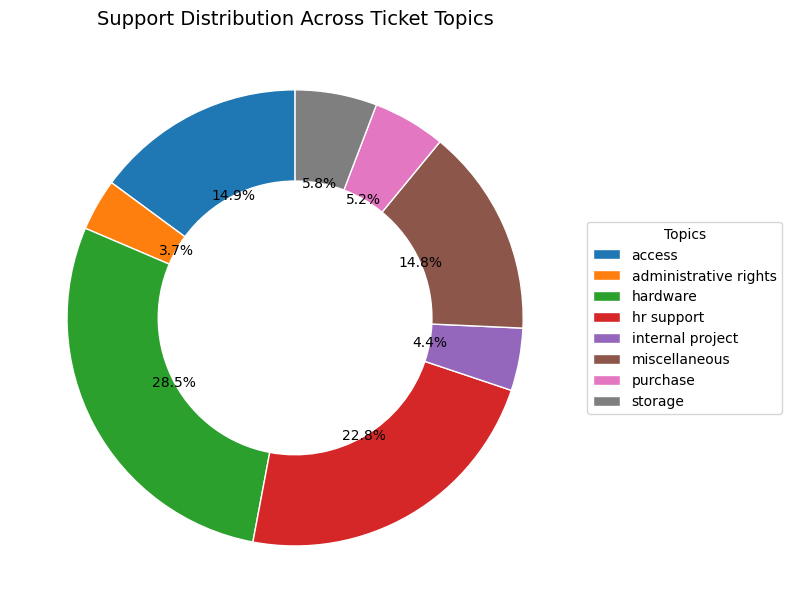

In [74]:
# Read classification report
report = pd.read_csv("classification_report_Topic Classification.csv", index_col=0)

# Remove summary rows
#report = report.loc[["Critical", "High", "Low", "Medium"]]
report = pd.read_csv("classification_report_Topic Classification.csv")
report = report[~report["Topic"].isin(
    ["accuracy", "macro avg", "weighted avg"]
)]
print(report)
plt.figure(figsize=(8, 8))

colors = plt.cm.Set3.colors

wedges, _, autotexts = plt.pie(
    report["support"],
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor="white")
)

plt.legend(
    wedges,
    report["Topic"],
    title="Topics",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Draw white circle in the center
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Support Distribution Across Ticket Topics", fontsize=14)
plt.savefig(
    "support_distribution_topics.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

   Priority  precision    recall  f1-score  support
0  Critical   0.928331  0.646127  0.761938   1704.0
1      High   0.877083  0.848790  0.862705    496.0
2       Low   0.804688  0.323899  0.461883    318.0
3    Medium   0.897594  0.989786  0.941438   7049.0


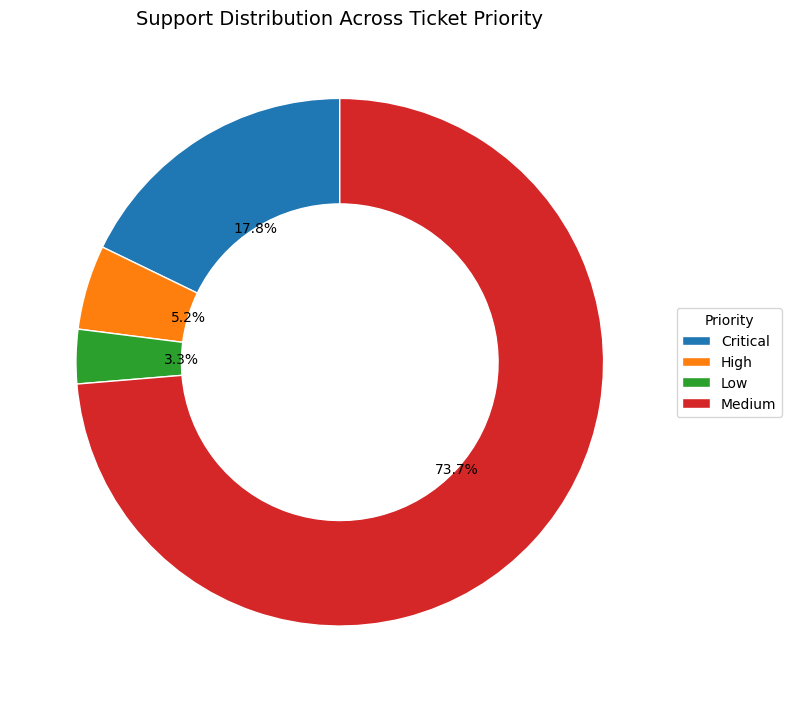

In [73]:
# Read classification report
report = pd.read_csv("classification_report_Topic Classification.csv", index_col=0)

# Remove summary rows
report = pd.read_csv("classification_report_Priority Classificatoin.csv")
report = report[~report["Priority"].isin(
    ["accuracy", "macro avg", "weighted avg"]
)]
print(report)
plt.figure(figsize=(8, 8))

colors = plt.cm.Set3.colors

wedges, _, autotexts = plt.pie(
    report["support"],
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor="white")
)

plt.legend(
    wedges,
    report["Priority"],
    title="Priority",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Draw white circle in the center
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Support Distribution Across Ticket Priority", fontsize=14)
plt.savefig(
    "support_distribution_priority.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()